In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')


In [18]:
df = pd.read_csv("nutrition_cf - Sheet5.csv")

# Show first few rows
df.head()


,Food,Associativity,Region,Type,Category,Allergy,Serving,Total Weight (gms),Energy(kcal),Proteins,Carbohydrates,Fats,Fiber,Carbon Footprint(kg CO2e),Ingredients
0,Soya flour Gobi stuffed paratha,1,"North,West","Breakfast,Lunch,Dinner",Veg,soy,2 medium,393,235,16.0,24.0,7.0,8.0,0.39450,Cauliflower-15 gms; Onion-15 gms; Ginger-4 gm...
1,DUMPLINGS (Veg),0,East,"Appetizer,Snacks",Veg,soy,4 medium,255,115,4.0,22.0,1.0,4.0,0.25955,carrot-15 gms; CABBAGE-15 gms; Capsicum-15 gms...
2,Baked Vegetables,0,Continental,Appetizer,Veg,soy,4 small,83,17,0.0,1.0,1.0,0.0,0.15840,Cauliflower-20 gms; carrot-20 gms;Capsicum-20 ...
3,LETTUCE WRAP (Chicken),0,Continental,"Lunch,Dinner",Non-veg,soy,1 medium,369,214,20.0,10.0,9.0,4.0,0.69985,Lettuce Leaf-20 gms; Chicken-70 gms; Tomato-12...
4,Soya Sizzler,6,Continental,"Lunch,Dinner",Veg,soy,1 medium,567,305,28.0,21.0,10.0,9.0,0.65800,Soyabean-30 gms; Ginger-15 gms;Garlic-15 gms; ...


In [4]:
# Basic info
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDataset Shape:", df.shape)

# Summary statistics
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Food                       753 non-null    object 
 1   Associativity              753 non-null    object 
 2   Region                     753 non-null    object 
 3   Type                       753 non-null    object 
 4   Category                   753 non-null    object 
 5   Allergy                    753 non-null    object 
 6   Serving                    753 non-null    object 
 7   Total Weight (gms)         753 non-null    int64  
 8   Energy(kcal)               753 non-null    int64  
 9   Proteins                   753 non-null    float64
 10  Carbohydrates              753 non-null    float64
 11  Fats                       753 non-null    float64
 12  Fiber                      753 non-null    float64
 13  Carbon Footprint(kg CO2e)  753 non-null    float64

,Total Weight (gms),Energy(kcal),Proteins,Carbohydrates,Fats,Fiber,Carbon Footprint(kg CO2e)
count,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000
mean,405.764940,259.310757,12.442629,32.025100,9.912882,7.127092,0.657318
std,278.924944,249.186947,18.894055,70.673733,14.048815,13.058121,0.684704
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,195.000000,98.000000,3.000000,8.000000,1.000000,2.000000,0.211600
50%,357.000000,192.000000,7.000000,18.000000,6.000000,4.000000,0.471500
75%,539.000000,331.000000,15.000000,38.000000,12.000000,9.000000,0.815500
max,2065.000000,1826.000000,275.000000,1548.000000,136.000000,288.000000,7.598950


In [19]:
print("Columns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())
print("\nShape:", df.shape)


Columns:
 Index(['Food', 'Associativity', 'Region', 'Type', 'Category', 'Allergy',
       'Serving', 'Total Weight (gms)', 'Energy(kcal)', 'Proteins',
       'Carbohydrates', 'Fats', 'Fiber', 'Carbon Footprint(kg CO2e)',
       'Ingredients'],
      dtype='object')

Missing Values:
 Food                         0
Associativity                0
Region                       0
Type                         0
Category                     0
Allergy                      0
Serving                      0
Total Weight (gms)           0
Energy(kcal)                 0
Proteins                     0
Carbohydrates                0
Fats                         0
Fiber                        0
Carbon Footprint(kg CO2e)    0
Ingredients                  0
dtype: int64

Shape: (753, 15)


In [20]:
# Fill numeric columns with mean
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(exclude=['float64', 'int64']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum()


Food                         0
Associativity                0
Region                       0
Type                         0
Category                     0
Allergy                      0
Serving                      0
Total Weight (gms)           0
Energy(kcal)                 0
Proteins                     0
Carbohydrates                0
Fats                         0
Fiber                        0
Carbon Footprint(kg CO2e)    0
Ingredients                  0
dtype: int64

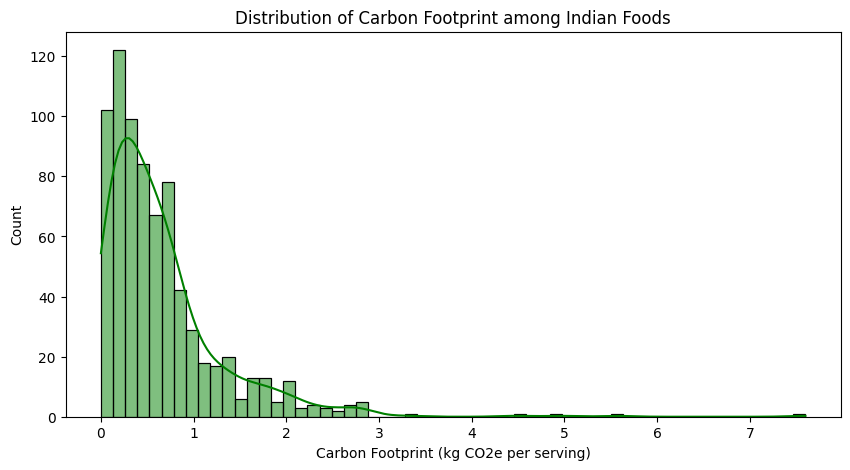

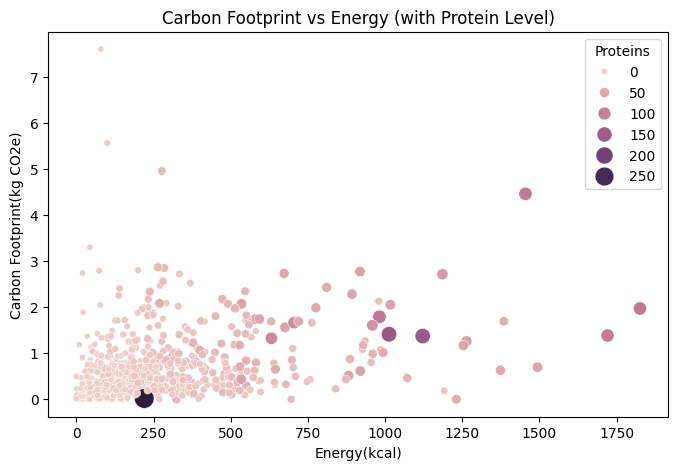

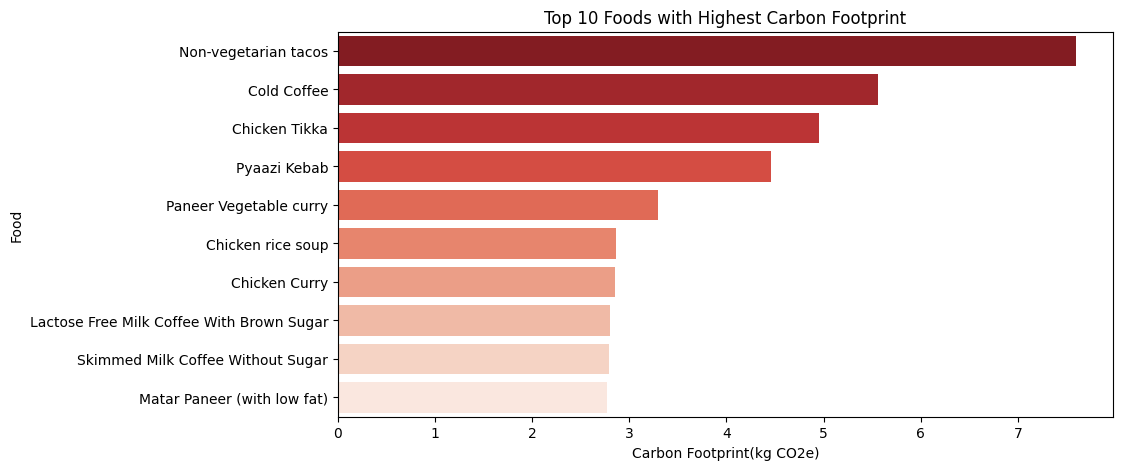

In [21]:
# Distribution of Carbon Footprint
plt.figure(figsize=(10,5))
sns.histplot(df['Carbon Footprint(kg CO2e)'], kde=True, color='green')
plt.title('Distribution of Carbon Footprint among Indian Foods')
plt.xlabel('Carbon Footprint (kg CO2e per serving)')
plt.ylabel('Count')
plt.show()

# Relationship between Carbon Footprint and Energy
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Energy(kcal)',
    y='Carbon Footprint(kg CO2e)',
    data=df,
    hue='Proteins',
    size='Proteins',
    sizes=(20,200)
)
plt.title('Carbon Footprint vs Energy (with Protein Level)')
plt.show()

# Top 10 foods with highest carbon footprint
top10 = df.nlargest(10, 'Carbon Footprint(kg CO2e)')[['Food', 'Carbon Footprint(kg CO2e)']]
plt.figure(figsize=(10,5))
sns.barplot(x='Carbon Footprint(kg CO2e)', y='Food', data=top10, palette='Reds_r')
plt.title('Top 10 Foods with Highest Carbon Footprint')
plt.show()


In [22]:
# Select key nutritional and sustainability features
features = ['Energy(kcal)', 'Proteins', 'Carbohydrates', 'Fats', 'Fiber', 'Carbon Footprint(kg CO2e)']

# Scale data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features])


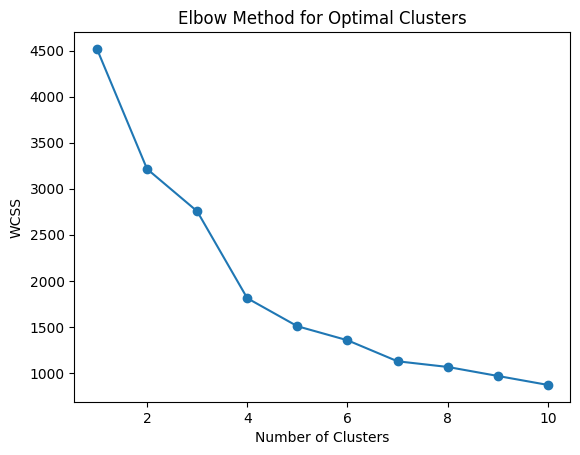

In [23]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


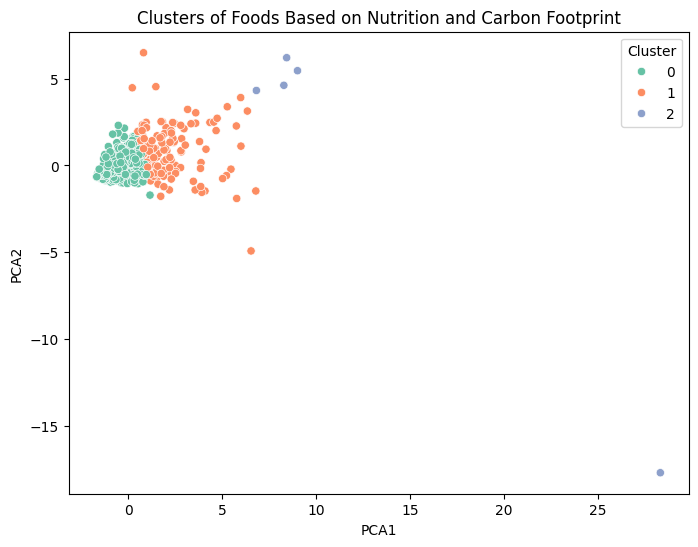

In [24]:
# Choose 3 clusters (based on elbow method)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

# Visualize clusters with PCA
pca = PCA(2)
pca_data = pca.fit_transform(scaled_features)
df['PCA1'] = pca_data[:,0]
df['PCA2'] = pca_data[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set2')
plt.title('Clusters of Foods Based on Nutrition and Carbon Footprint')
plt.show()


In [25]:
cluster_summary = df.groupby('Cluster')[['Energy(kcal)', 'Proteins', 'Fats', 'Fiber', 'Carbon Footprint(kg CO2e)']].mean()
print("Cluster Summary:\n", cluster_summary)

eco_cluster = cluster_summary['Carbon Footprint(kg CO2e)'].idxmin()
eco_foods = df[df['Cluster'] == eco_cluster][['Food', 'Carbon Footprint(kg CO2e)', 'Energy(kcal)', 'Proteins']]
print("\n✅ Eco-Friendly Foods (Lowest Carbon Cluster):\n", eco_foods.head(10))


Cluster Summary:
          Energy(kcal)    Proteins        Fats      Fiber  \
Cluster                                                    
0          173.208738    7.136408    6.045955   5.038350   
1          627.776923   33.223077   24.246154  14.761538   
2         1321.400000  128.000000  115.200000  66.800000   

         Carbon Footprint(kg CO2e)  
Cluster                             
0                         0.521987  
1                         1.252706  
2                         1.904050  

✅ Eco-Friendly Foods (Lowest Carbon Cluster):
                                Food  Carbon Footprint(kg CO2e)  Energy(kcal)  \
0   Soya flour Gobi stuffed paratha                    0.39450           235   
1                   DUMPLINGS (Veg)                    0.25955           115   
2                  Baked Vegetables                    0.15840            17   
3            LETTUCE WRAP (Chicken)                    0.69985           214   
4                      Soya Sizzler             

In [26]:
df.to_csv("clustered_indian_diet_sustainability.csv", index=False)
print("✅ Clustered dataset saved successfully!")


✅ Clustered dataset saved successfully!
